# Name: Shamir Maharjan
# Student ID: 2417731

# Task 3: Perceptron Algorithm for 3 vs 5 Classification.

In [1]:
import pandas as pd
import numpy as np
# Load the dataset
df_0_1 = pd.read_csv("C:\\Users\\LOQ\\semester 6\\AIML\\Workshop 3\\mnist_3_and_5.csv") 
# Extract features and labels
X = df_0_1.drop(columns=["label"]).values # 784 pixels
y = df_0_1["label"].values # Labels (0 or 1)
# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


### Visualize the Dataset:

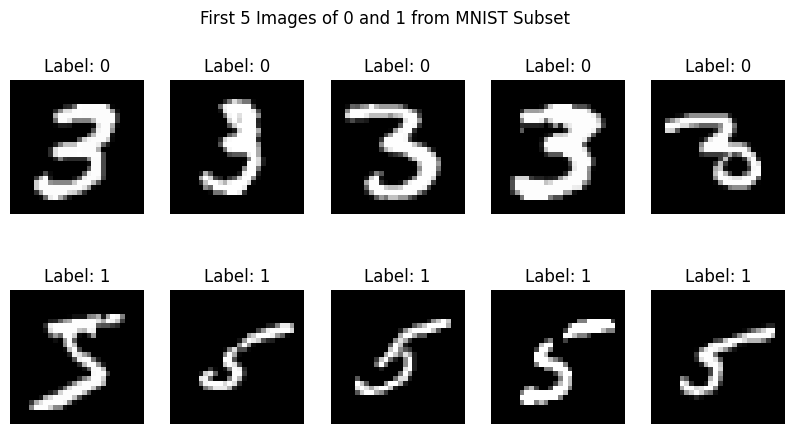

In [4]:
import matplotlib.pyplot as plt
# Separate images for label 0 and label 1
images_3 = X[y == 3] # Get all images with label 3
images_5 = X[y == 5] # Get all images with label 5
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
# Check if the arrays have the required amount of data
if len(images_3) < 5 or len(images_5) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
    # Plot digit 0
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
    # Plot digit 1
        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
plt.show()

### Initialize Weights and Bias:

In [5]:
# Initialize weights and bias
weights = np.zeros(X.shape[1]) # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

## Implement a Decision Function or Activation Function:

In [9]:
import numpy as np
def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.
    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training
    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias
    #####Your Code Here############ # Activation function (step function)
    y_pred_all = np.where(predictions >= 3, 5, 3);  # np.where(condition, value_if_true, value_if_false)
    return y_pred_all

## Implement the Perceptron Learning Algorithm:

In [10]:
import numpy as np
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.
    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)
    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """
    for epoch in range(epochs):
        correct_count = 0
        y_pred_all = decision_function(X, weights, bias)

        for i in range(X.shape[0]):
            X_sample = X[i]
            y_pred_single = y_pred_all[i]
            y_true = y[i]

            error = y_true - y_pred_single

            if error !=0:
                weights = weights + learning_rate * error * X_sample
                bias = bias + learning_rate * error
            else:
                correct_count +=1

        if (epoch + 1) % 10 ==0:
            epoch_accuracy = (correct_count/ X.shape[0]) * 100
            print(f"Epoch {epoch+1}, Accuracy: {epoch_accuracy:.2f}%")

    y_pred_final = decision_function(X, weights, bias)
    accuracy = np.sum(y_pred_final == y) / len(y) * 100

    return weights, bias, accuracy

In [11]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)
# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

Epoch 10, Accuracy: 45.86%
Epoch 20, Accuracy: 45.86%
Epoch 30, Accuracy: 45.86%
Epoch 40, Accuracy: 45.86%
Epoch 50, Accuracy: 45.86%
Epoch 60, Accuracy: 45.86%
Epoch 70, Accuracy: 45.86%
Epoch 80, Accuracy: 45.86%
Epoch 90, Accuracy: 45.86%
Epoch 100, Accuracy: 45.86%
The Final Accuracy is:  45.859175483400215


## Visualizing the Misclassified Image:

Final Accuracy: 0.4586


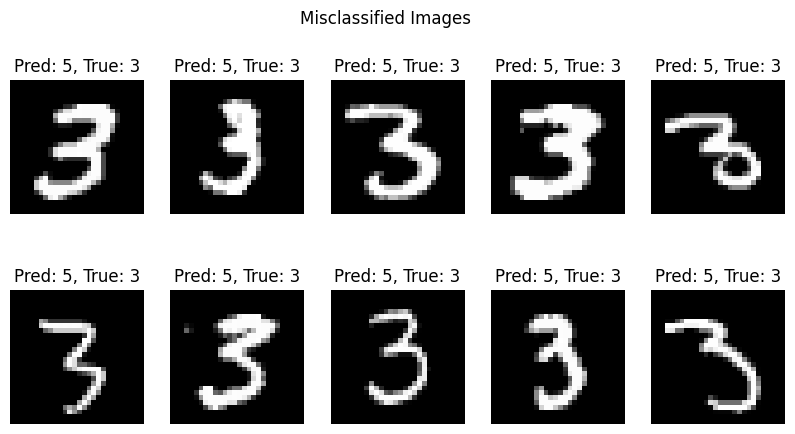

In [13]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 3, 5, 3)
# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")
# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]): # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")